# Small judge panels: cost vs. performance under DIAL

Reads `results/real_robustness/` produced by

```bash
python run_real_data.py --study robustness --sweep budget --methods consensus_cal,dial_mu --seeds 0:50 --workers 12
```

after adding the `small6`/`large6` panels to `configs/real_robustness.toml`. Answers: does a
cheap, small-model-only judge panel, run through the same DIAL calibration as every other
real-data result, match (i) human-only evaluation and (ii) a large-model or the full 21-judge
panel, at a fraction of the parameter count and with zero paid API calls?

**Panels** (`[panels]` in `configs/real_robustness.toml`), six open-weight judges each, no paid
API judges in either tier, split by disclosed parameter count with a deliberate size gap:

- `small6` (<=9B): DeepSeek-R1 1.5B/7B/8B, Starling-LM 7B, GLM-4 9B, Gemma-3n e4b (~4B effective)
  -- 36.5B total parameters.
- `large6` (>=20B): GPT-OSS 20B, Mistral-Small 24B, Gemma-3 27B, Qwen3-30B-A3B, DeepSeek-R1 32B,
  Llama-3.3 70B -- 203B total parameters, about 5.6x `small6`.
- `all`: the paper's existing full 21-judge panel (18 open-weight judges, 367.5B+ disclosed
  parameters, plus 3 paid-API judges of undisclosed size) -- the upper-bound reference.

No latency, token, or dollar-cost logging exists anywhere in this repo (checked directly against
`data/*/results/*/metadata.json` and `data/judge_query/`), so parameter count is the only
measured, verifiable cost proxy used here; the `small6`/`large6` split isolates model capacity
while holding panel size fixed at 6 judges.

Figure layout: 3 rows (Chatbot Arena, MT-Bench, PandaLM) x 3 columns (`small6`, `large6`, `all`).


In [1]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
from experiments.real_data.robustness_plot import load, aggregate
from experiments.style import STYLE, LABEL, RCPARAMS, INK_SOFT, GRID, DATASET_LABEL, method_lines, legend_handles

FIGURES = REPO / "figures"
mpl.rcParams.update(RCPARAMS)

DATASETS = ["arena_33k", "mt_bench", "pandalm"]
METHODS = ["human_only", "consensus_cal", "dial_mu"]
PANELS = ["small6", "large6", "all"]
PARAMS_B = {"small6": 1.5 + 7 + 8 + 7 + 9 + 4, "large6": 20 + 24 + 27 + 30 + 32 + 70}
PANEL_TITLE = {
    "small6": "small6 (%.1fB)" % PARAMS_B["small6"],
    "large6": "large6 (%.0fB)" % PARAMS_B["large6"],
    "all": "all, 21 judges (367.5B+, 3 paid APIs)",
}

AGG = {}
for ds in DATASETS:
    df = load(ds, REPO)
    a = aggregate(df)
    print(f"{ds}: seeds={df.seed.nunique()}  rows={len(df)}  failed={int(df.failed.sum())}")
    # human_only was computed once per dataset, for panel="all" (it does not depend on the LLM
    # panel at all -- `--methods consensus_cal,dial_mu` skipped recomputing it for small6/large6
    # on purpose). Copy those rows onto small6/large6, for both sweeps, so every column shows the
    # same Human line.
    ho = a[(a.panel == "all") & (a.method == "human_only") & (a.sweep.isin(["budget", "llm_budget"]))]
    AGG[ds] = pd.concat([a] + [ho.assign(panel=p) for p in ("small6", "large6")], ignore_index=True)


arena_33k: seeds=50  rows=36150  failed=0


mt_bench: seeds=50  rows=27900  failed=0


pandalm: seeds=50  rows=27900  failed=0


### Pretest: Cons-Cal / DIAL-$\mu$ switch gated on the calibration-restriction test

Chat-only diagnostic, not in the paper. Uses the manuscript's own `calibration_restriction_test`
(\Cref{prop:calibration-test}, $H_0: s_{\human}=\alpha\mu$) instead of GACV: fail to reject at
level $\alpha$ -> Cons-Cal; reject -> DIAL-$\mu$'s already GACV-selected fit. No new fits -- both
candidates are already in `rows.jsonl`; only the $p$-value is new (cheap: one
`fit_consensus_only_calibrated` per cell, no GACV grid search), precomputed by a one-off script
into `/tmp/pretest_pvalues_full.parquet` since it is not part of the saved schema.

In [2]:
PRETEST_ALPHA = 0.05
STYLE["pretest"] = dict(color="#8e44ad", ls="-.", marker="D", lw=1.2)
LABEL["pretest"] = f"Pretest ($\\alpha$={PRETEST_ALPHA})"
METHODS_PT = METHODS + ["pretest"]

pv = pd.read_parquet("/tmp/pretest_pvalues_full.parquet")  # dataset, panel, level, seed, pvalue


def _se(x):
    x = x.dropna()
    return x.std(ddof=1) / len(x) ** 0.5 if len(x) > 1 else float("nan")


for ds in DATASETS:
    raw = load(ds, REPO)
    sub = raw[(raw.sweep == "budget") & (raw.panel.isin(PANELS)) & (raw.method.isin(["consensus_cal", "dial_mu"])) & (~raw.failed)]
    piv = sub.pivot_table(index=["panel", "level", "seed"], values=["excess", "ref_kendall", "n_H"], columns="method")
    piv.columns = [f"{m}_{c}" for c, m in piv.columns]
    piv = piv.reset_index()
    m = piv.merge(pv[pv.dataset == ds][["panel", "level", "seed", "pvalue"]], on=["panel", "level", "seed"], how="inner")
    use_dial = m["pvalue"] < PRETEST_ALPHA
    m["excess"] = m["dial_mu_excess"].where(use_dial, m["consensus_cal_excess"])
    m["ref_kendall"] = m["dial_mu_ref_kendall"].where(use_dial, m["consensus_cal_ref_kendall"])
    m["n_H"] = m["consensus_cal_n_H"]
    g = m.groupby(["panel", "level"]).agg(
        excess_mean=("excess", "mean"), excess_se=("excess", _se),
        ref_kendall_mean=("ref_kendall", "mean"), ref_kendall_se=("ref_kendall", _se),
        n_H_mean=("n_H", "mean"),
    ).reset_index()
    g["sweep"] = "budget"; g["kind"] = "none"; g["method"] = "pretest"; g["n_H_level"] = -1
    AGG[ds] = pd.concat([AGG[ds], g], ignore_index=True)
    print(f"{ds}: pretest used DIAL-mu on {100*use_dial.mean():.1f}% of joined cells")


arena_33k: pretest used DIAL-mu on 20.6% of joined cells


mt_bench: pretest used DIAL-mu on 6.6% of joined cells


pandalm: pretest used DIAL-mu on 3.8% of joined cells


In [3]:
def curve(ax, a, sweep, panel, kind, methods, x="level", n_H_level=None, logx=False, hline_human=True, band=True, metric="excess"):
    """One panel of the curve figures: `method_lines` for the methods, human-only as a flat line
    when the x axis is not the human budget itself. Copied verbatim from
    notebooks/real_data_robustness.ipynb so the two studies stay visually identical."""
    g = a[(a.sweep == sweep) & (a.panel == panel) & (a.kind == kind)]
    if n_H_level is not None: g = g[g.n_H_level == n_H_level]
    if g.empty: ax.text(0.5, 0.5, "not run", ha="center", va="center", transform=ax.transAxes, color=INK_SOFT); return
    g = g.assign(_x=g["n_H_mean"] if x == "n_H" else g["level"])
    if hline_human and x != "n_H" and (g.method == "human_only").any():
        ax.axhline(g.loc[g.method == "human_only", f"{metric}_mean"].mean(), color=STYLE["human_only"]["color"], ls="-", lw=1.0)
        methods = [m for m in methods if m != "human_only"]
    method_lines(ax, g, "_x", f"{metric}_mean", methods, se=f"{metric}_se", band=band, se_exclude=("human_only",))
    if logx: ax.set_xscale("log"); ax.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    ax.grid(True, color=GRID, lw=0.5); ax.tick_params(length=2.5)


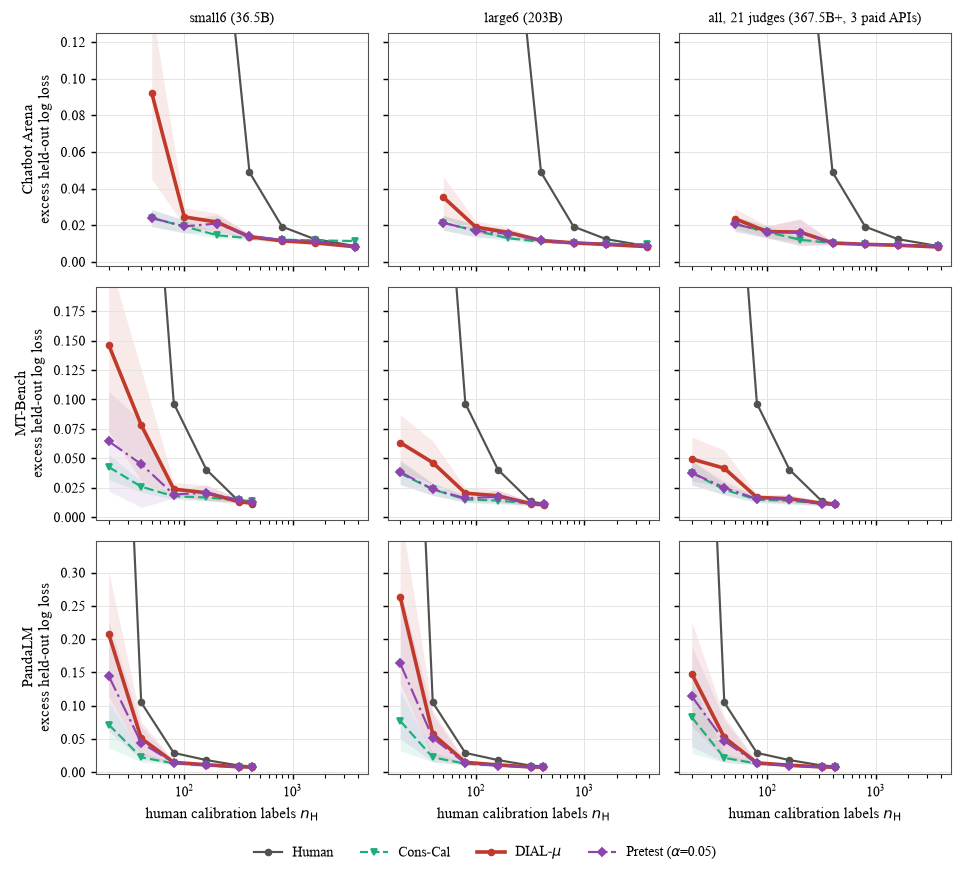

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(7.4, 6.6), sharex="col", sharey="row")
for row, ds in enumerate(DATASETS):
    agg = AGG[ds]
    g_row = agg[(agg.sweep == "budget") & (agg.panel.isin(PANELS)) & (agg.method != "human_only") & (agg.method.isin(METHODS_PT))]
    for col, panel in enumerate(PANELS):
        ax = axes[row, col]
        curve(ax, agg, "budget", panel, "none", METHODS_PT, x="n_H", logx=True, hline_human=False)
        if row == 0:
            ax.set_title(PANEL_TITLE[panel], fontsize=8)
        if row == len(DATASETS) - 1:
            ax.set_xlabel("human calibration labels $n_{\\mathrm{H}}$")
    axes[row, 0].set_ylim(-0.002, g_row.excess_mean.max() * 1.3 + 0.005)  # shared within the row; set once
    axes[row, 0].set_ylabel(f"{DATASET_LABEL[ds]}\nexcess held-out log loss")
h, l = legend_handles(METHODS_PT)
fig.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=(0, 0.02, 1, 1))
fig.savefig(FIGURES / "fig_small_panel_pretest.pdf", bbox_inches="tight")
plt.show()


### Kendall's tau against the held-out human ranking (same 3x3 layout)

Same panels/rows/columns/methods as the excess-log-loss figure above, `metric="ref_kendall"` instead. Higher is better. Chat-only diagnostic, not in the paper.

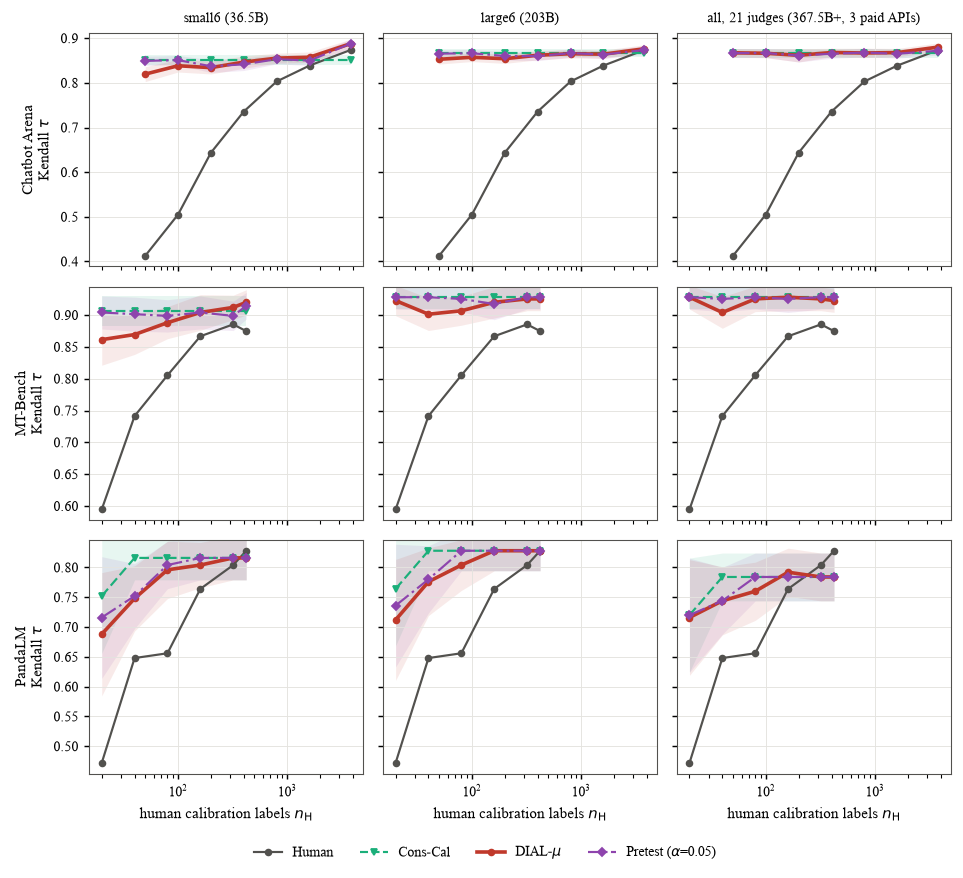

In [5]:
fig_tau, axes_tau = plt.subplots(3, 3, figsize=(7.4, 6.6), sharex="col", sharey="row")
for row, ds in enumerate(DATASETS):
    agg = AGG[ds]
    g_row = agg[(agg.sweep == "budget") & (agg.panel.isin(PANELS)) & (agg.method.isin(METHODS_PT))]
    for col, panel in enumerate(PANELS):
        ax = axes_tau[row, col]
        curve(ax, agg, "budget", panel, "none", METHODS_PT, x="n_H", logx=True, hline_human=False, metric="ref_kendall")
        if row == 0:
            ax.set_title(PANEL_TITLE[panel], fontsize=8)
        if row == len(DATASETS) - 1:
            ax.set_xlabel("human calibration labels $n_{\\mathrm{H}}$")
    lo, hi = g_row.ref_kendall_mean.min(), g_row.ref_kendall_mean.max()
    pad = 0.05 * (hi - lo) if hi > lo else 0.02
    axes_tau[row, 0].set_ylim(lo - pad, hi + pad)
    axes_tau[row, 0].set_ylabel(f"{DATASET_LABEL[ds]}\nKendall $\\tau$")
h, l = legend_handles(METHODS_PT)
fig_tau.legend(h, l, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig_tau.tight_layout(rect=(0, 0.02, 1, 1))
fig_tau.savefig(FIGURES / "fig_small_panel_pretest_tau.pdf", bbox_inches="tight")
plt.show()


### Numbers behind the figure (all three datasets)

Full pool and the smallest swept human budget, for the paper's G.4.2 text.

In [6]:
print("panel total parameters (B):", PARAMS_B, " ratio large6/small6 = %.2f" % (PARAMS_B["large6"] / PARAMS_B["small6"]))
print()

rows = []
for ds in DATASETS:
    sub = AGG[ds][(AGG[ds].sweep == "budget") & (AGG[ds].panel.isin(PANELS)) & (AGG[ds].method.isin(METHODS))]
    lo = sub.loc[sub.level > 0, "level"].min()
    for lvl, tag in [(-1.0, "full pool"), (lo, f"n_H={int(lo)}")]:
        for panel in PANELS:
            for method in METHODS:
                r = sub[(sub.level == lvl) & (sub.panel == panel) & (sub.method == method)]
                if r.empty:
                    continue
                r = r.iloc[0]
                rows.append(dict(dataset=ds, budget=tag, panel=panel, method=method,
                                  n_H=round(r.n_H_mean), excess=round(r.excess_mean, 4), excess_se=round(r.excess_se, 4),
                                  kendall=round(r.ref_kendall_mean, 3)))
table = pd.DataFrame(rows)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
print(table.to_string(index=False))


panel total parameters (B): {'small6': 36.5, 'large6': 203}  ratio large6/small6 = 5.56

  dataset    budget  panel        method  n_H  excess  excess_se  kendall
arena_33k full pool small6    human_only 3802  0.0086     0.0004    0.874
arena_33k full pool small6 consensus_cal 3802  0.0114     0.0005    0.851
arena_33k full pool small6       dial_mu 3802  0.0083     0.0004    0.888
arena_33k full pool large6    human_only 3802  0.0086     0.0004    0.874
arena_33k full pool large6 consensus_cal 3802  0.0096     0.0004    0.866
arena_33k full pool large6       dial_mu 3802  0.0084     0.0004    0.876
arena_33k full pool    all    human_only 3802  0.0086     0.0004    0.874
arena_33k full pool    all consensus_cal 3802  0.0089     0.0004    0.867
arena_33k full pool    all       dial_mu 3802  0.0081     0.0004    0.880
arena_33k    n_H=50 small6    human_only   50  6.6515     0.4614    0.412
arena_33k    n_H=50 small6 consensus_cal   50  0.0239     0.0024    0.851
arena_33k    n_H=50 sma

## LLM budget: fewer records per judge, at a fixed human budget

Chat-only diagnostic, not in the paper. Everything above fixes the *judges* (panel) and varies
the human budget $n_{\mathrm{H}}$, using every as-collected LLM record. Here instead: fix
$n_{\mathrm{H}}$ at the paper's own default calibration sample ($300$/$80$/$60$) and subsample
the balanced LLM rows themselves down to $n_{\mathrm{L}}$ -- the `llm_budget` sweep already used
for \Cref{fig:real}(e-g)/\Cref{fig:real-efficiency} (bottom), now also computed for `small6`/`large6`
(`configs/real_robustness.toml` `[sweeps.llm_budget]`, `panels` extended the same way as `budget`).
Answers a second, complementary cost question: alongside fewer/smaller judges, does the small
panel also tolerate fewer records per judge?

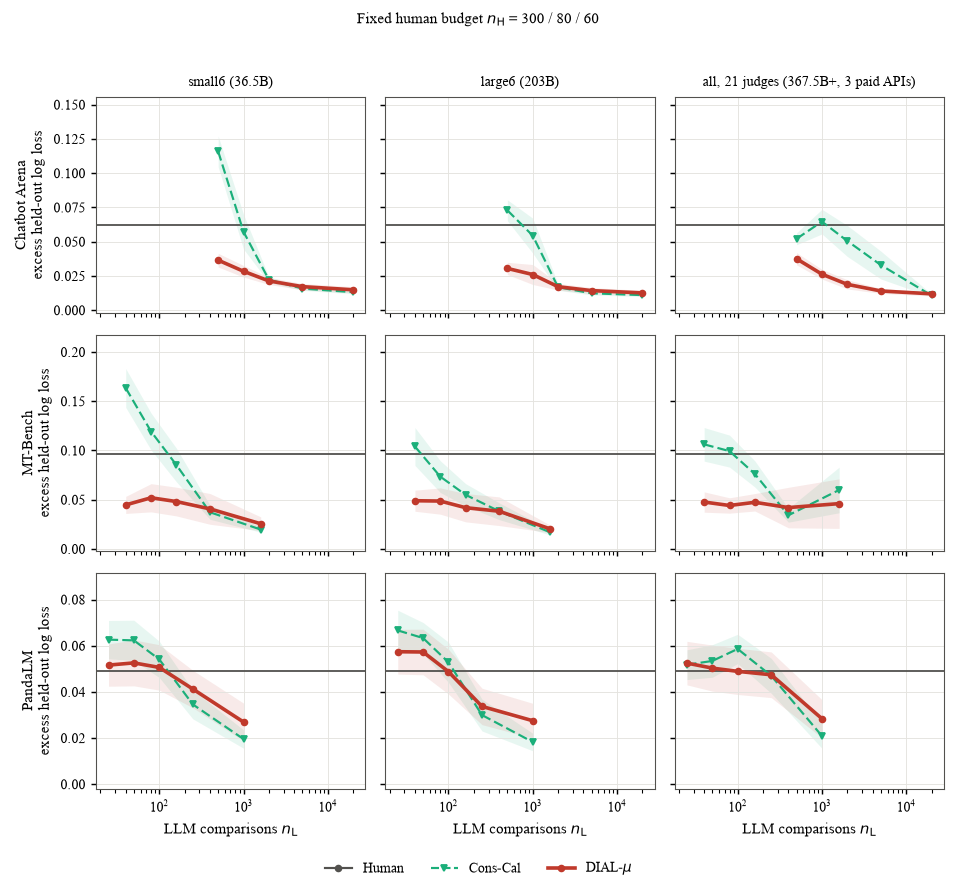

In [7]:
NH_FIXED = {"arena_33k": 300, "mt_bench": 80, "pandalm": 60}

fig_l, axes_l = plt.subplots(3, 3, figsize=(7.4, 6.6), sharex="col", sharey="row")
for row, ds in enumerate(DATASETS):
    agg = AGG[ds]
    g_row = agg[(agg.sweep == "llm_budget") & (agg.panel.isin(PANELS)) & (agg.n_H_level == NH_FIXED[ds]) & (agg.method != "human_only") & (agg.method.isin(METHODS))]
    for col, panel in enumerate(PANELS):
        ax = axes_l[row, col]
        curve(ax, agg, "llm_budget", panel, "none", METHODS, x="level", n_H_level=NH_FIXED[ds], logx=True)
        if row == 0:
            ax.set_title(PANEL_TITLE[panel], fontsize=8)
        if row == len(DATASETS) - 1:
            ax.set_xlabel("LLM comparisons $n_{\\mathrm{L}}$")
    axes_l[row, 0].set_ylim(-0.002, g_row.excess_mean.max() * 1.3 + 0.005)
    axes_l[row, 0].set_ylabel(f"{DATASET_LABEL[ds]}\nexcess held-out log loss")
h, l = legend_handles(METHODS)
fig_l.legend(h, l, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
nh_label = "%d / %d / %d" % (NH_FIXED["arena_33k"], NH_FIXED["mt_bench"], NH_FIXED["pandalm"])
fig_l.suptitle("Fixed human budget $n_{\\mathrm{H}}$ = " + nh_label, y=1.0, fontsize=8.5)
fig_l.tight_layout(rect=(0, 0.02, 1, 0.98))
fig_l.savefig(FIGURES / "fig_small_panel_llmbudget.pdf", bbox_inches="tight")
plt.show()


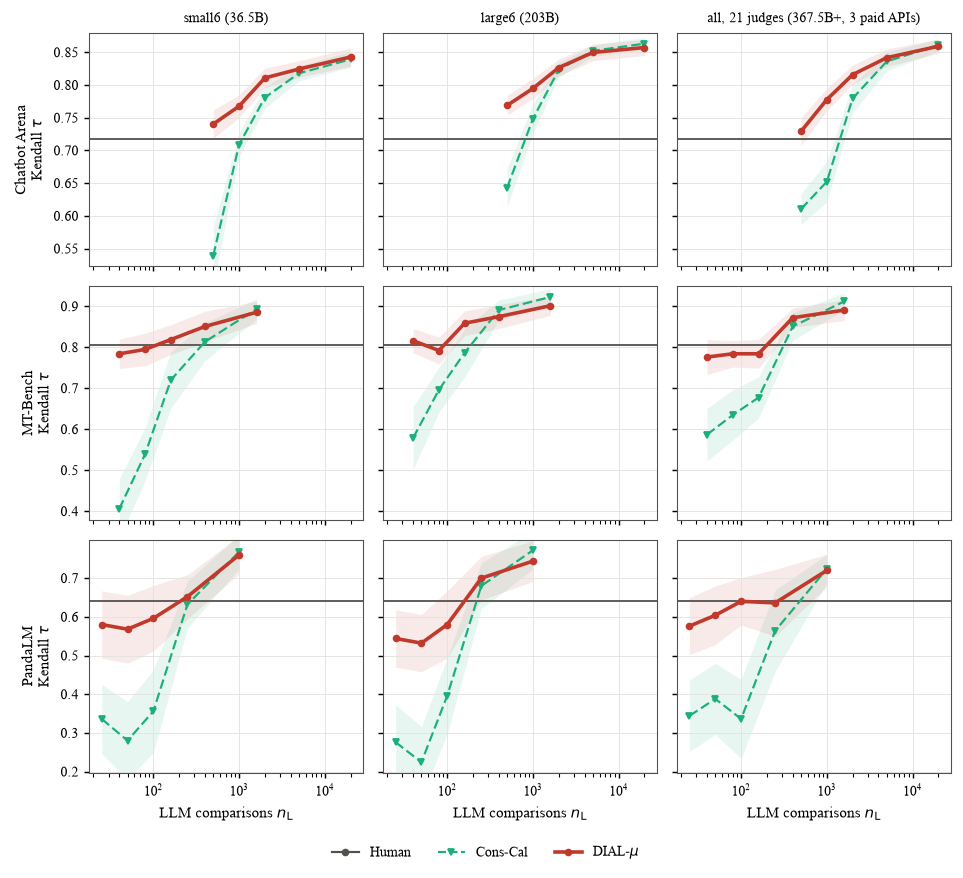

In [8]:
fig_lt, axes_lt = plt.subplots(3, 3, figsize=(7.4, 6.6), sharex="col", sharey="row")
for row, ds in enumerate(DATASETS):
    agg = AGG[ds]
    g_row = agg[(agg.sweep == "llm_budget") & (agg.panel.isin(PANELS)) & (agg.n_H_level == NH_FIXED[ds]) & (agg.method.isin(METHODS))]
    for col, panel in enumerate(PANELS):
        ax = axes_lt[row, col]
        curve(ax, agg, "llm_budget", panel, "none", METHODS, x="level", n_H_level=NH_FIXED[ds], logx=True, metric="ref_kendall")
        if row == 0:
            ax.set_title(PANEL_TITLE[panel], fontsize=8)
        if row == len(DATASETS) - 1:
            ax.set_xlabel("LLM comparisons $n_{\\mathrm{L}}$")
    lo, hi = g_row.ref_kendall_mean.min(), g_row.ref_kendall_mean.max()
    pad = 0.05 * (hi - lo) if hi > lo else 0.02
    axes_lt[row, 0].set_ylim(lo - pad, hi + pad)
    axes_lt[row, 0].set_ylabel(f"{DATASET_LABEL[ds]}\nKendall $\\tau$")
h, l = legend_handles(METHODS)
fig_lt.legend(h, l, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig_lt.tight_layout(rect=(0, 0.02, 1, 1))
fig_lt.savefig(FIGURES / "fig_small_panel_llmbudget_tau.pdf", bbox_inches="tight")
plt.show()


## Appendix G.4.2: raw and adaptive DIAL-mu

These are the authoritative exports for both manuscript plots.
They retain all three judge panels and use 50 matched seeds for every curve.
DIAL-mu (raw) is the original GACV choice; DIAL-mu applies the fixed c=1 endpoint margin.
The exploratory pretest plots above now use separate filenames.
Run the expanded experiment first if needed:
`python -m experiments.real_data.endpoint_margin --seeds 50 --workers 8 --panels all small6 large6 --out results/endpoint_margin_appendix`


In [ ]:
from experiments.real_data.small_panel_appendix import make_figures
appendix_summary = make_figures(REPO / "results" / "endpoint_margin_appendix", FIGURES)
print("Both G.4.2 plots exported with 50 matched seeds and raw/adaptive DIAL-mu labels.")
